In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
filename = r"C:\Users\cgrif\PycharmProjects\JuMBOs\data\raw\Hillenbrand_ONC.dat"
df = pd.read_csv(filename, delim_whitespace=True, header=None)
# Combine RA (1–3) and Dec (4–6)
df["RA"]  = df[1].astype(str) + " " + df[2].astype(str) + " " + df[3].astype(str)
df["Dec"] = df[4].astype(str) + " " + df[5].astype(str) + " " + df[6].astype(str)

# Keep only the useful columns
df = df[[0, "RA", "Dec", 7, 8, 9]]
df.columns = ["ID", "RA", "Dec", "col4", "col5", "mag"]

df.head()

,ID,RA,Dec,col4,col5,mag
0,1,5 34 11.42,-5 30 19.44,-1.00,-1.00,17.67
1,2,5 34 11.6,-5 33 55.63,0.90,0.42,19.34
2,3,5 34 12.81,-5 28 47.81,0.24,0.51,16.80
3,4,5 34 12.97,-5 33 48.05,0.49,0.19,18.98
4,5,5 34 13.12,-5 33 53.25,-1.00,-1.00,19.00


In [3]:
from astropy.coordinates import Angle
import astropy.units as u
df = df.copy()
df["RA_deg"]  = df["RA"].apply(lambda x: Angle(x, unit=u.hourangle).degree)
df["Dec_deg"] = df["Dec"].apply(lambda x: Angle(x, unit=u.deg).degree)

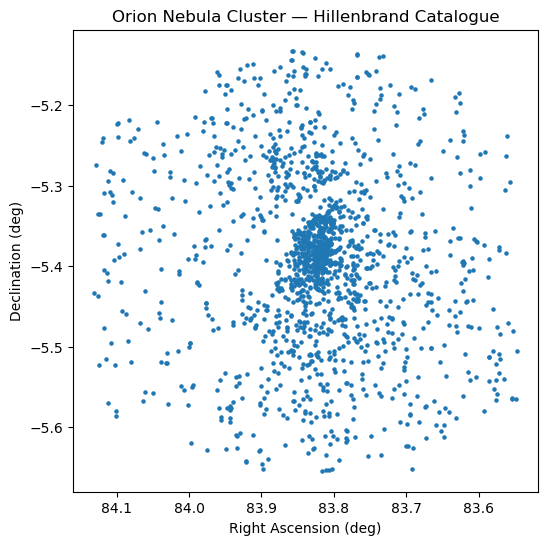

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(df["RA_deg"], df["Dec_deg"], s=5)
plt.gca().invert_xaxis()  # RA increases to the left
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title("Orion Nebula Cluster — Hillenbrand Catalogue")
plt.show()

In [5]:
# Creating fake dataset
ra_min, ra_max = df["RA_deg"].min(), df["RA_deg"].max()
dec_min, dec_max = df["Dec_deg"].min(), df["Dec_deg"].max()
n_stars = len(df)

print(f"RA range:  {ra_min:.3f}–{ra_max:.3f}")
print(f"Dec range: {dec_min:.3f}–{dec_max:.3f}")
print(f"Number of stars: {n_stars}")

RA range:  83.548–84.131
Dec range: -5.654–-5.132
Number of stars: 1576


In [6]:
fake = pd.DataFrame({
    "RA_deg": np.random.uniform(ra_min, ra_max, n_stars),
    "Dec_deg": np.random.uniform(dec_min, dec_max, n_stars)
})

In [7]:
def make_fake_set(df, scale=1.0, seed=None):
    """
    Generate a random 'fake' star catalogue covering the same RA/Dec range as an existing dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        The reference dataset (must have 'RA_deg' and 'Dec_deg' columns).
    scale : float, optional
        Factor by which to change the number of fake stars (default = 1.0 → same number).
        e.g. scale=5 makes 5× as many stars as the real dataset.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    fake : pandas.DataFrame
        A DataFrame with random RA/Dec coordinates (columns: RA_deg, Dec_deg).
    """

    if seed is not None:
        np.random.seed(seed)

    # Get coordinate range from real data
    ra_min, ra_max = df["RA_deg"].min(), df["RA_deg"].max()
    dec_min, dec_max = df["Dec_deg"].min(), df["Dec_deg"].max()

    n_stars = int(len(df) * scale)

    # Create random coordinates
    fake = pd.DataFrame({
        "RA_deg": np.random.uniform(ra_min, ra_max, n_stars),
        "Dec_deg": np.random.uniform(dec_min, dec_max, n_stars)
    })

    return fake

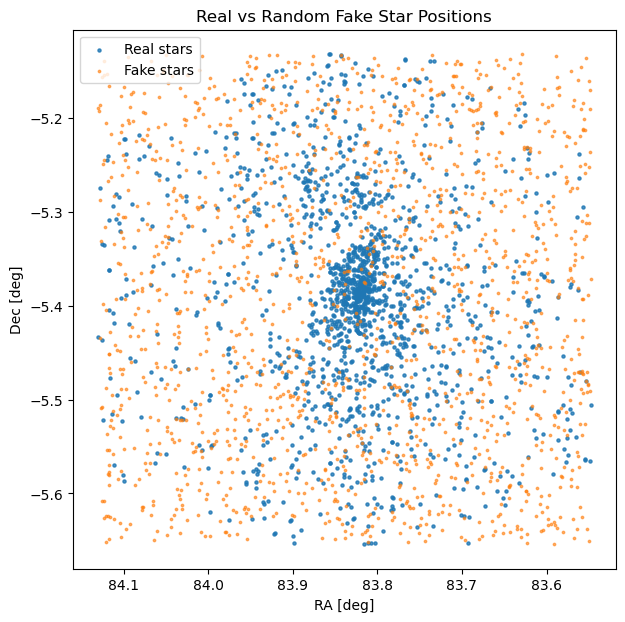

In [8]:
plt.figure(figsize=(7, 7))

# Real stars
plt.scatter(df["RA_deg"], df["Dec_deg"], s=5, alpha=0.8, label="Real stars")

# Fake stars
plt.scatter(fake["RA_deg"], fake["Dec_deg"], s=3, alpha=0.6, label="Fake stars")

plt.gca().invert_xaxis()
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Real vs Random Fake Star Positions")
plt.legend()
plt.show()

In [9]:
from astropy.coordinates import SkyCoord

D_PC = 390        # ONC distance in parsec (Maiz Apellaniz 2023)
N_PAIRS = 50          # number of random pairs

# Coordinates object for all fake stars
coords = SkyCoord(ra=fake["RA_deg"].values * u.deg,
                  dec=fake["Dec_deg"].values * u.deg)

# Randomly pick 50 pairs (no star reused)
randoms = np.random.choice(len(fake), size=2 * N_PAIRS, replace=False)
pairs = randoms.reshape(N_PAIRS, 2)

# Angular separations
sep = coords[pairs[:, 0]].separation(coords[pairs[:, 1]])      # Angle
sep_arcsec = sep.to(u.arcsec).value                            # float angles in arcsec

# Convert to AU
dist_au = sep_arcsec * D_PC

# Collect results
pairs_df = pd.DataFrame({
    "i1": pairs[:, 0],
    "i2": pairs[:, 1],
    "RA1_deg": fake["RA_deg"].values[pairs[:, 0]],
    "Dec1_deg": fake["Dec_deg"].values[pairs[:, 0]],
    "RA2_deg": fake["RA_deg"].values[pairs[:, 1]],
    "Dec2_deg": fake["Dec_deg"].values[pairs[:, 1]],
    "sep_arcsec": sep_arcsec,
    "sep_AU": dist_au
})

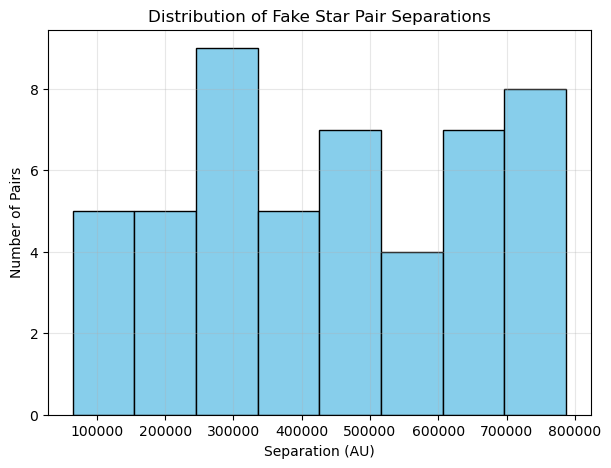

In [10]:
plt.figure(figsize=(7, 5))
plt.hist(pairs_df["sep_AU"], bins=8, color="skyblue", edgecolor="black")
plt.xlabel("Separation (AU)")
plt.ylabel("Number of Pairs")
plt.title("Distribution of Fake Star Pair Separations")
plt.grid(alpha=0.3)
plt.show()

In [11]:
# Week 2 

In [12]:
fake5 = make_fake_set(df, scale=5)

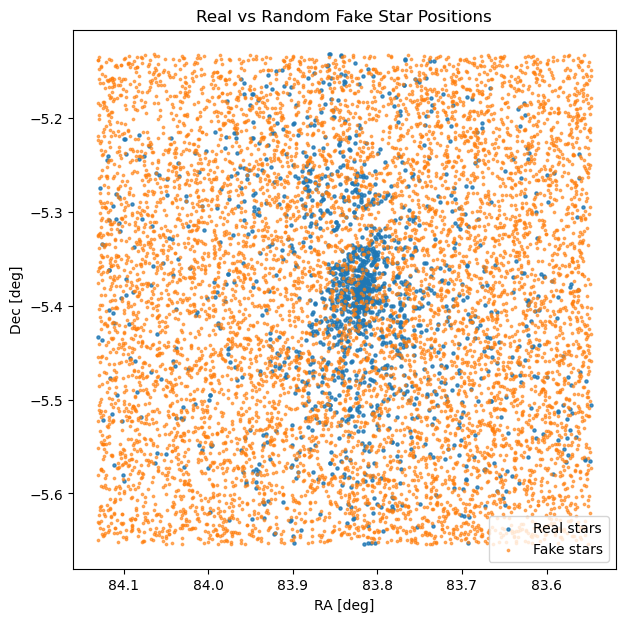

In [13]:
plt.figure(figsize=(7, 7))

# Real stars
plt.scatter(df["RA_deg"], df["Dec_deg"], s=5, alpha=0.8, label="Real stars")

# Fake stars
plt.scatter(fake5["RA_deg"], fake5["Dec_deg"], s=3, alpha=0.6, label="Fake stars")

plt.gca().invert_xaxis()
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Real vs Random Fake Star Positions")
plt.legend()
plt.show()

In [14]:
def random_pair_separations(df, n_pairs=50, distance_pc=390, seed=None,
                            plot=False, xlim=None, logx=False, bins=30):
    """
    Randomly select pairs of stars from a catalog and compute their separations.

    Parameters
    ----------
    df : pandas.DataFrame
        Catalog with 'RA_deg' and 'Dec_deg' columns (decimal degrees).
    n_pairs : int, optional
        Number of random pairs (default 50).
    distance_pc : float, optional
        Distance to cluster in parsecs (for arcsec → AU conversion).
    seed : int, optional
        Random seed for reproducibility.
    plot : bool, optional
        If True, show a histogram of separations (default False).
    xlim : tuple or None, optional
        (xmin, xmax) for x-axis limits in AU, e.g. (0, 1000).
    logx : bool, optional
        Plot x-axis on a log scale if True.
    bins : int, optional
        Number of histogram bins.

    Returns
    -------
    pairs_df : pandas.DataFrame
        DataFrame with columns:
        ['i1', 'i2', 'RA1_deg', 'Dec1_deg', 'RA2_deg', 'Dec2_deg',
         'sep_arcsec', 'sep_AU']
    """

    if seed is not None:
        np.random.seed(seed)

    # --- Make coordinate object
    coords = SkyCoord(ra=df["RA_deg"].values * u.deg,
                      dec=df["Dec_deg"].values * u.deg)

    # --- Random unique pairs
    idx = np.random.choice(len(df), size=2 * n_pairs, replace=False)
    pairs = idx.reshape(n_pairs, 2)

    # --- Separations
    sep = coords[pairs[:, 0]].separation(coords[pairs[:, 1]])
    sep_arcsec = sep.to(u.arcsec).value
    sep_AU = sep_arcsec * distance_pc

    # --- Result DataFrame
    pairs_df = pd.DataFrame({
        "i1": pairs[:, 0],
        "i2": pairs[:, 1],
        "RA1_deg": df["RA_deg"].values[pairs[:, 0]],
        "Dec1_deg": df["Dec_deg"].values[pairs[:, 0]],
        "RA2_deg": df["RA_deg"].values[pairs[:, 1]],
        "Dec2_deg": df["Dec_deg"].values[pairs[:, 1]],
        "sep_arcsec": sep_arcsec,
        "sep_AU": sep_AU
    })

    # --- Optional plot
    if plot:
        plt.figure(figsize=(7,5))
        plt.hist(sep_AU, bins=bins, color="skyblue", edgecolor="black")
        plt.xlabel("Separation (AU)")
        plt.ylabel("Number of pairs")
        plt.title(f"Random pair separations ({n_pairs} pairs)")
        if logx:
            plt.xscale("log")
        if xlim is not None:
            plt.xlim(xlim)
        plt.grid(alpha=0.3)
        plt.show()

    return pairs_df


def compare_random_pair_seps(dfs, labels, n_pairs=100, distance_pc=414,
                             seeds=None, logx=False, xlim=None,
                             bins=30, density=False, alpha=0.6):
    """
    Compute and plot random-pair separation histograms for multiple catalogs.

    Parameters
    ----------
    dfs : list[pd.DataFrame]
        Each must have 'RA_deg' and 'Dec_deg'.
    labels : list[str]
        Legend labels, same length as dfs.
    n_pairs : int
        Pairs per dataset (same for each for fair comparison).
    distance_pc : float
        Distance used for arcsec->AU.
    seeds : list[int] or None
        Optional seeds per dataset (len matches dfs) for reproducibility.
    logx : bool
        If True, use log-x and log-spaced bins.
    xlim : tuple or None
        (xmin, xmax) in AU.
    bins : int
        Number of bins.
    density : bool
        If True, normalize histograms to probability density.
    alpha : float
        Histogram transparency.

    Returns
    -------
    results : dict[label -> pd.DataFrame]
        Each value is the pairs_df for that dataset.
    """
    assert len(dfs) == len(labels), "dfs and labels must match in length"
    if seeds is not None:
        assert len(seeds) == len(dfs), "seeds length must match dfs"

    results = {}
    seps = []

    # Compute separations for each dataset
    for k, (df, lab) in enumerate(zip(dfs, labels)):
        seed = None if seeds is None else seeds[k]
        pairs_df = random_pair_separations(df, n_pairs=n_pairs,
                                           distance_pc=distance_pc, seed=seed)
        results[lab] = pairs_df
        seps.append(pairs_df["sep_AU"].values)

    # Choose common bins
    all_vals = np.concatenate(seps)
    if xlim is None:
        xmin, xmax = float(np.min(all_vals)), float(np.max(all_vals))
    else:
        xmin, xmax = xlim

    if logx:
        xmin = max(xmin, 1e-6)  # prevent log(0)
        bin_edges = np.logspace(np.log10(xmin), np.log10(xmax), bins)
    else:
        bin_edges = np.linspace(xmin, xmax, bins)

    # Plot
    plt.figure(figsize=(7, 5))
    for arr, lab in zip(seps, labels):
        plt.hist(arr, bins=bin_edges, alpha=alpha, label=lab, density=density)

    if logx:
        plt.xscale("log")
    if xlim is not None:
        plt.xlim(xlim)

    plt.xlabel("Random pair separation (AU)")
    plt.ylabel("Density" if density else "Number of pairs")
    plt.title(f"Random pair separations (n_pairs per set = {n_pairs})")
    plt.grid(True, which="both" if logx else "major", alpha=0.3)
    plt.legend()
    plt.show()

    return results

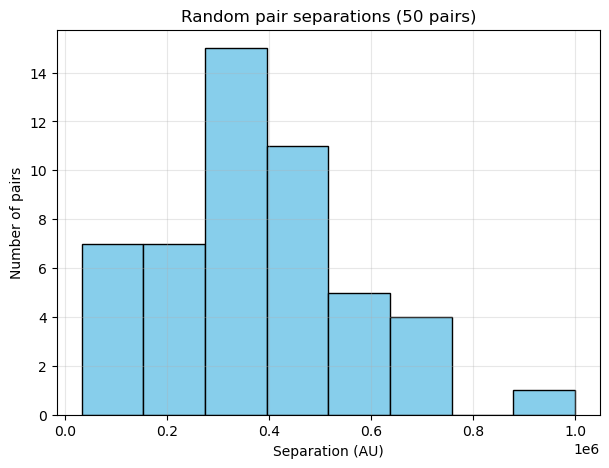

In [15]:
pairs_5x = random_pair_separations(fake5, n_pairs=50, bins = 8,
                                   plot=True, logx=False)

In [16]:

def nearest_neighbours(
    df,
    distance_pc=390,
    edge_margin_deg=None,
    plot=False,
    bins=50,
    logx=False,
    xlim=None,
    density=False,
    title="Nearest-neighbour separations",
):
    """
    Compute nearest-neighbour separations for a catalog of sky coordinates.

    This function uses `astropy.coordinates.match_to_catalog_sky` with
    `nthneighbor=2` to efficiently find, for each object, its nearest
    *other* neighbour (the 1st match is always itself).  It scales as
    O(N log N), so it runs much faster than a full pairwise search.

    Parameters
    ----------
    df : pandas.DataFrame
        Catalog containing columns 'RA_deg' and 'Dec_deg' (decimal degrees).
    distance_pc : float, optional
        Distance to the system in parsecs. Used to convert arcsec → AU.
        Default = 414 pc (ONC distance).
    edge_margin_deg : float or None, optional
        If set, removes all stars within this angular margin (deg) of any
        field boundary before computing nearest neighbours.  This mitigates
        the upward bias in NN separations near the edges.
    plot : bool, optional
        If True, show a histogram of nearest-neighbour separations (AU).
    bins : int or array-like, optional
        Number of histogram bins or explicit bin edges (default = 30).
    logx : bool, optional
        If True, plot the x-axis on a logarithmic scale.
    xlim : tuple or None, optional
        (xmin, xmax) limits for the x-axis in AU.
    density : bool, optional
        If True, normalize the histogram to a probability density.
    title : str, optional
        Title for the plot.

    Returns
    -------
    nn_df : pandas.DataFrame
        DataFrame of nearest neighbours with columns:
            'i'          → index of the source star within the (trimmed) input df
            'j_nn'       → index of its nearest neighbour
            'nn_arcsec'  → angular separation to nearest neighbour (arcsec)
            'nn_AU'      → physical separation (AU)
            'RA_deg'     → RA of source star (deg)
            'Dec_deg'    → Dec of source star (deg)

    Notes
    -----
    - Uses a KD-tree search internally; efficient even for large N.
    - Each star always has exactly one nearest neighbour.
    - For plotting performance, use logx=True when separations span many
      orders of magnitude.
    """

    # --- Optional edge trimming to reduce boundary bias ---
    work = df
    if edge_margin_deg is not None:
        ra_min, ra_max = df["RA_deg"].min(), df["RA_deg"].max()
        de_min, de_max = df["Dec_deg"].min(), df["Dec_deg"].max()
        work = df[
            (df["RA_deg"]  > ra_min + edge_margin_deg) &
            (df["RA_deg"]  < ra_max - edge_margin_deg) &
            (df["Dec_deg"] > de_min + edge_margin_deg) &
            (df["Dec_deg"] < de_max - edge_margin_deg)
        ].copy()
        if len(work) == 0:
            raise ValueError("Edge trimming removed all rows; reduce edge_margin_deg.")

    # --- Coordinate object ---
    coords = SkyCoord(ra=work["RA_deg"].values * u.deg,
                      dec=work["Dec_deg"].values * u.deg)

    # --- KD-tree nearest neighbour search (O[N log N]) ---
    j_nn, sep2d, _ = coords.match_to_catalog_sky(coords, nthneighbor=2)

    nn_df = pd.DataFrame({
        "i": np.arange(len(work), dtype=int),
        "j_nn": j_nn.astype(int),
        "nn_arcsec": sep2d.to(u.arcsec).value
    })
    nn_df["nn_AU"] = nn_df["nn_arcsec"] * distance_pc
    nn_df["RA_deg"]  = work["RA_deg"].values[nn_df["i"]]
    nn_df["Dec_deg"] = work["Dec_deg"].values[nn_df["i"]]

    # --- Optional histogram ---
    if plot:
        vals = nn_df["nn_AU"].values
        plt.figure(figsize=(7,5))
        plt.hist(vals, bins=bins, density=density, edgecolor="black")
        if logx:
            plt.xscale("log")
        if xlim is not None:
            plt.xlim(xlim)
        plt.xlabel("Nearest-neighbour separation (AU)")
        plt.ylabel("Density" if density else "Number of stars")
        plt.title(title)
        plt.grid(True, which="both" if logx else "major", alpha=0.3)
        plt.show()

    return nn_df

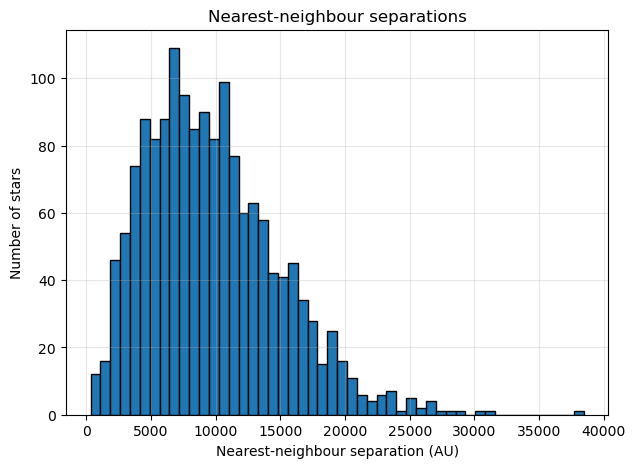

In [17]:
nn_fake = nearest_neighbours(fake, plot=True, bins=50)

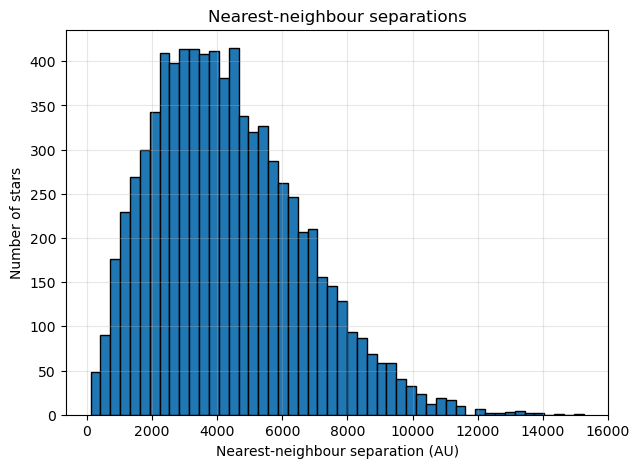

In [18]:
nn_fake5 = nearest_neighbours(fake5, plot=True, bins=50)

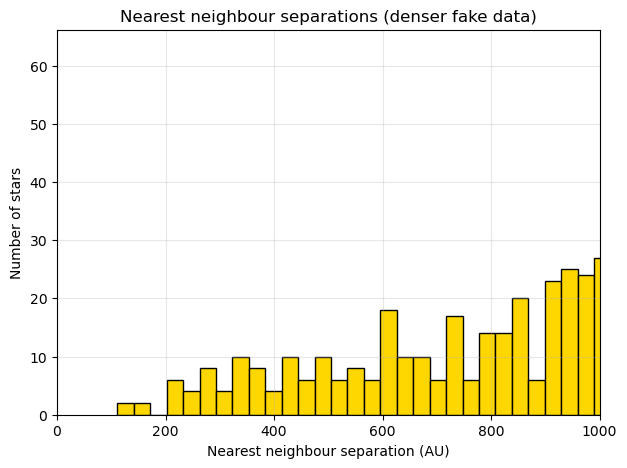

In [19]:
plt.figure(figsize=(7,5))
plt.hist(nn_fake5["nn_AU"], bins=500, color="gold", edgecolor="black")
plt.xlabel("Nearest neighbour separation (AU)")
plt.ylabel("Number of stars")
plt.title("Nearest neighbour separations (denser fake data)")
plt.grid(alpha=0.3)
plt.xlim(0, 1000)
plt.show()

In [20]:
# Read JuMBOs data
filename = r"C:\Users\cgrif\PycharmProjects\JuMBOs\data\raw\Jumbo_catalogue.dat"
jumbos = pd.read_csv(filename, delim_whitespace=True, header=None)

In [21]:
jumbos.columns = [
    "Name", "RA_deg", "Dec_deg",
    "Mass_1", "col_4", "mass_2", "col_6",
    "sep_au", "col9", "col10"
]
jumbos = jumbos.drop(columns=["col9", "col10"])

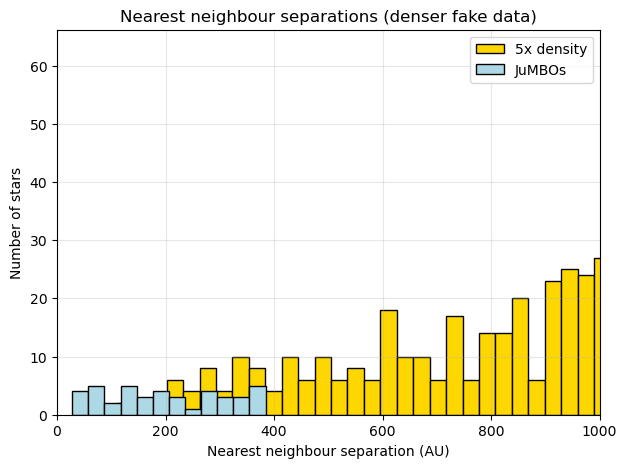

In [22]:
plt.figure(figsize=(7,5))
plt.hist(nn_fake5["nn_AU"], bins=500, color="gold", edgecolor="black", label = '5x density')
plt.hist(jumbos["sep_au"], bins = 12, color='lightblue', edgecolor="black", label = 'JuMBOs')
plt.xlabel("Nearest neighbour separation (AU)")
plt.ylabel("Number of stars")
plt.title("Nearest neighbour separations (denser fake data)")
plt.grid(alpha=0.3)
plt.xlim(0, 1000)
plt.legend()
plt.show()

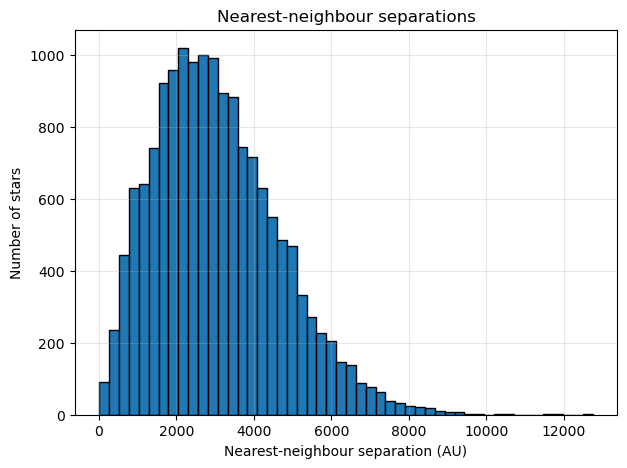

In [23]:
fake10 = make_fake_set(df, scale=10)
nn_fake10 = nearest_neighbours(fake10, plot=True, bins=50)

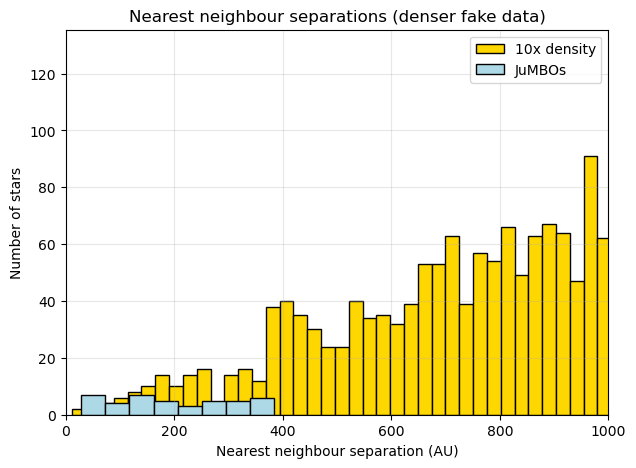

In [24]:
plt.figure(figsize=(7,5))
plt.hist(nn_fake10["nn_AU"], bins=500, color="gold", edgecolor="black", label = '10x density')
plt.hist(jumbos["sep_au"], bins = 8, color='lightblue', edgecolor="black", label = 'JuMBOs')
plt.xlabel("Nearest neighbour separation (AU)")
plt.ylabel("Number of stars")
plt.title("Nearest neighbour separations (denser fake data)")
plt.grid(alpha=0.3)
plt.xlim(0, 1000)
plt.legend()
plt.show()

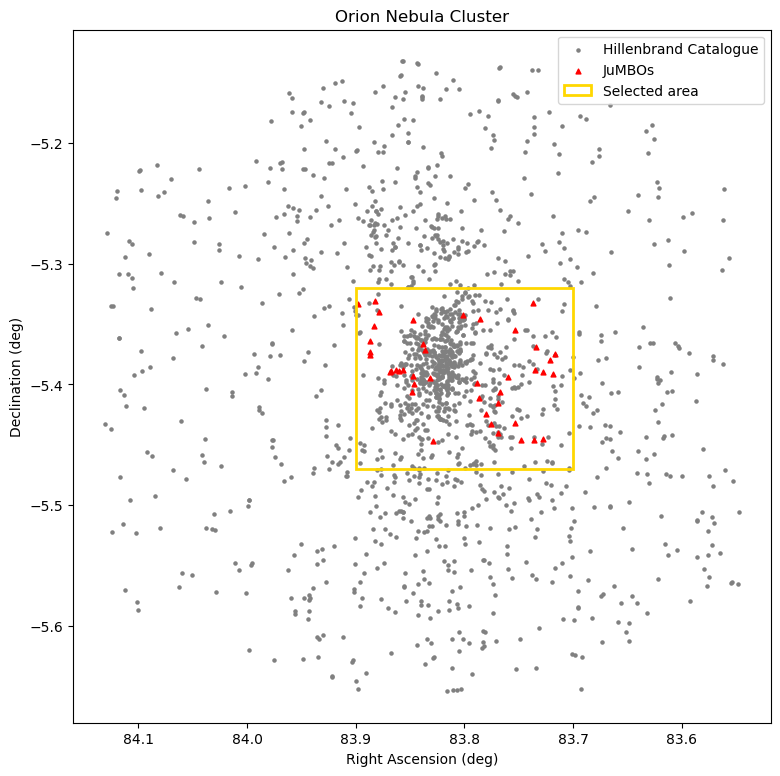

In [25]:
# Limits for chosen subregion (edit)
ra_min_sel, ra_max_sel = 83.7, 83.9
dec_min_sel, dec_max_sel = -5.47, -5.32



plt.figure(figsize=(9, 9))
plt.scatter(df["RA_deg"], df["Dec_deg"], s=5, color = 'gray', label = 'Hillenbrand Catalogue')
plt.scatter(jumbos["RA_deg"], jumbos["Dec_deg"], s=12, color = 'r', marker = '^', label = 'JuMBOs')
plt.gca().invert_xaxis()  # RA increases to the left
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title("Orion Nebula Cluster")

# Draw a rectangle showing the selection
rect = plt.Rectangle(
    (ra_min_sel, dec_min_sel),
    ra_max_sel - ra_min_sel,
    dec_max_sel - dec_min_sel,
    linewidth=2,
    edgecolor="gold",
    facecolor="none",
    label="Selected area"
)
plt.gca().add_patch(rect)

plt.legend()
plt.show()

In [26]:
# Filter to subregion
onc_sub_jumbo = df[
    (df["RA_deg"] >= ra_min_sel) & (df["RA_deg"] <= ra_max_sel) &
    (df["Dec_deg"] >= dec_min_sel) & (df["Dec_deg"] <= dec_max_sel)
]
print(f"Selected region: {len(onc_sub_jumbo)} stars")

Selected region: 695 stars


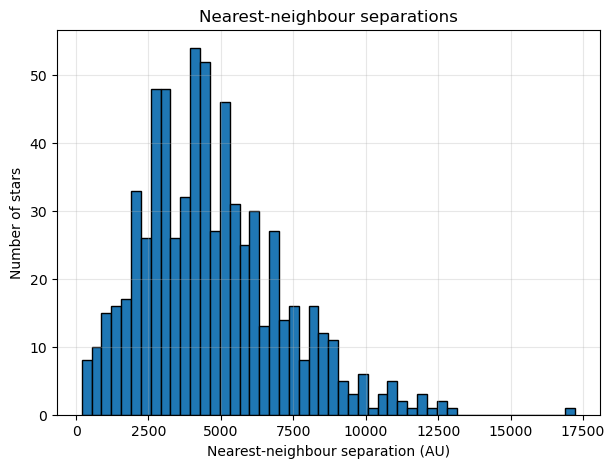

In [27]:
# Use functions on smaller subregion

fake_sub_jumbo = make_fake_set(onc_sub_jumbo, scale=1)
nn_sub_jumbo = nearest_neighbours(fake_sub_jumbo, plot=True, bins=50)

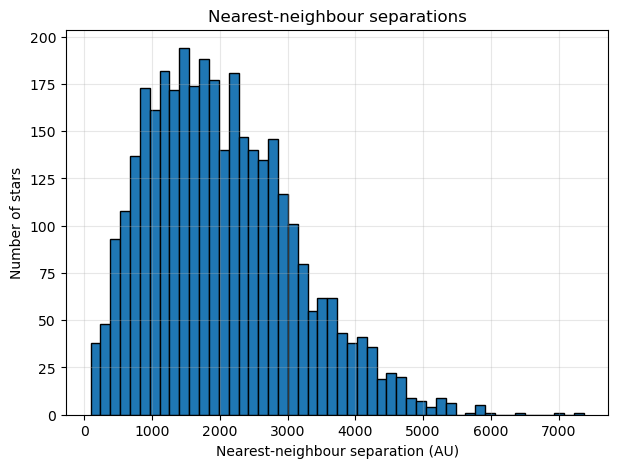

In [28]:
fake_sub_5_jumbo = make_fake_set(onc_sub_jumbo, scale=5)
nn_sub_5_jumbo = nearest_neighbours(fake_sub_5_jumbo, plot=True, bins=50)

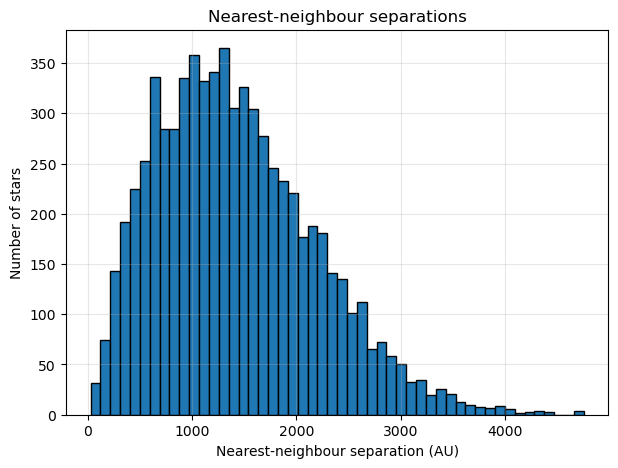

In [29]:
fake_sub_10_jumbo = make_fake_set(onc_sub_jumbo, scale=10)
nn_sub_10_jumbo = nearest_neighbours(fake_sub_10_jumbo, plot=True, bins=50)

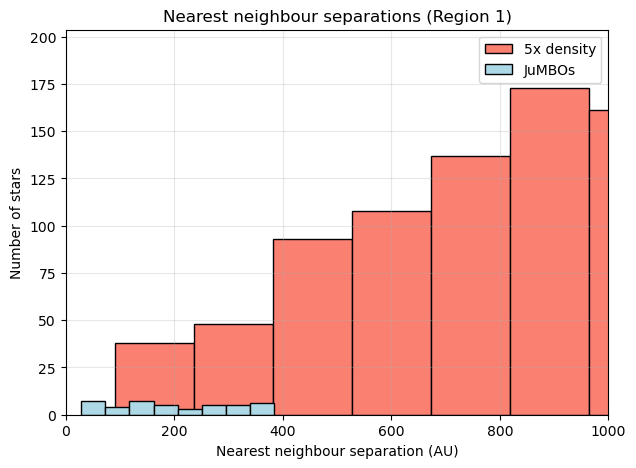

In [30]:
plt.figure(figsize=(7,5))
plt.hist(nn_sub_5_jumbo["nn_AU"], bins=50, color="salmon", edgecolor="black", label = '5x density')
plt.hist(jumbos["sep_au"], bins = 8, color='lightblue', edgecolor="black", label = 'JuMBOs')
plt.xlabel("Nearest neighbour separation (AU)")
plt.ylabel("Number of stars")
plt.title("Nearest neighbour separations (Region 1)")
plt.grid(alpha=0.3)
plt.xlim(0, 1000)
plt.legend()
plt.show()

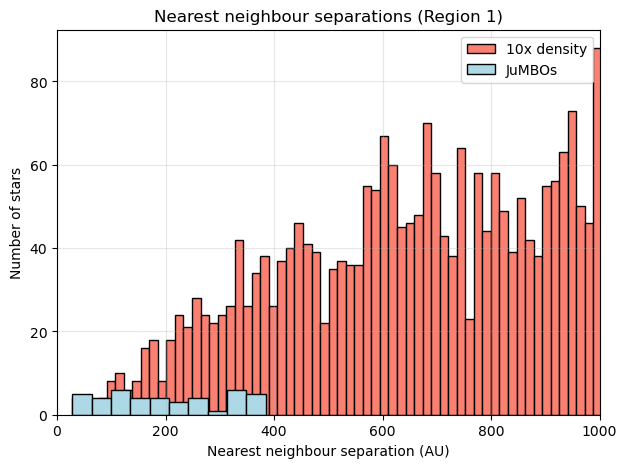

In [31]:
plt.figure(figsize=(7,5))
plt.hist(nn_sub_10_jumbo["nn_AU"], bins=300, color="salmon", edgecolor="black", label = '10x density')
plt.hist(jumbos["sep_au"], bins = 10, color='lightblue', edgecolor="black", label = 'JuMBOs')
plt.xlabel("Nearest neighbour separation (AU)")
plt.ylabel("Number of stars")
plt.title("Nearest neighbour separations (Region 1)")
plt.grid(alpha=0.3)
plt.xlim(0, 1000)

plt.legend()
plt.show()

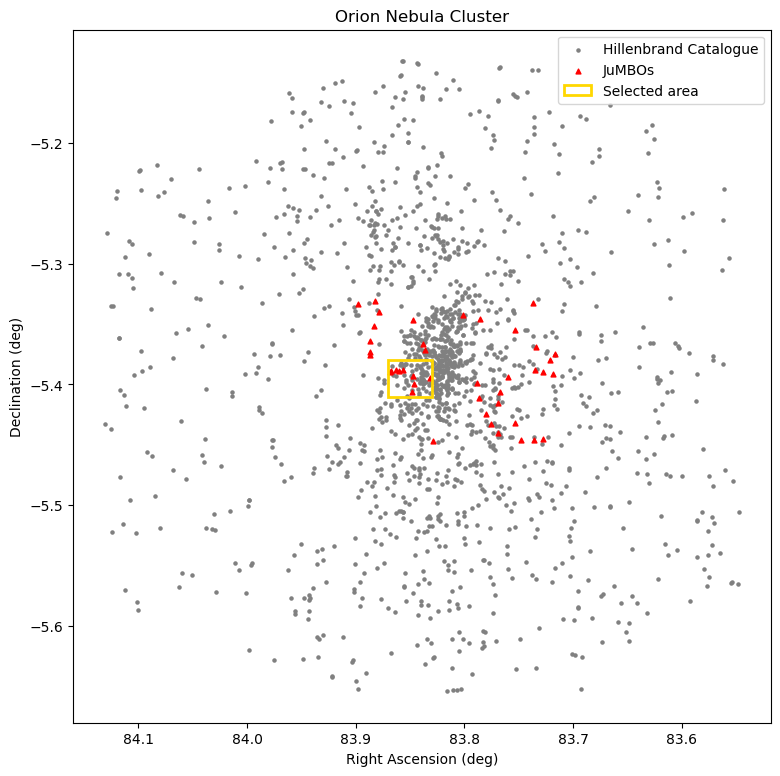

In [32]:
# Limits for chosen subregion (edit)
ra_min_sel, ra_max_sel = 83.83, 83.87
dec_min_sel, dec_max_sel = -5.41, -5.38



plt.figure(figsize=(9, 9))
plt.scatter(df["RA_deg"], df["Dec_deg"], s=5, color = 'gray', label = 'Hillenbrand Catalogue')
plt.scatter(jumbos["RA_deg"], jumbos["Dec_deg"], s=12, color = 'r', marker = '^', label = 'JuMBOs')
plt.gca().invert_xaxis()  # RA increases to the left
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title("Orion Nebula Cluster")

# Draw a rectangle showing the selection
rect = plt.Rectangle(
    (ra_min_sel, dec_min_sel),
    ra_max_sel - ra_min_sel,
    dec_max_sel - dec_min_sel,
    linewidth=2,
    edgecolor="gold",
    facecolor="none",
    label="Selected area"
)
plt.gca().add_patch(rect)

plt.legend()
plt.show()

In [33]:
# Filter to subregion
onc_sub_2 = df[
    (df["RA_deg"] >= ra_min_sel) & (df["RA_deg"] <= ra_max_sel) &
    (df["Dec_deg"] >= dec_min_sel) & (df["Dec_deg"] <= dec_max_sel)
]
print(f"Selected region: {len(onc_sub_2)} stars")

Selected region: 57 stars


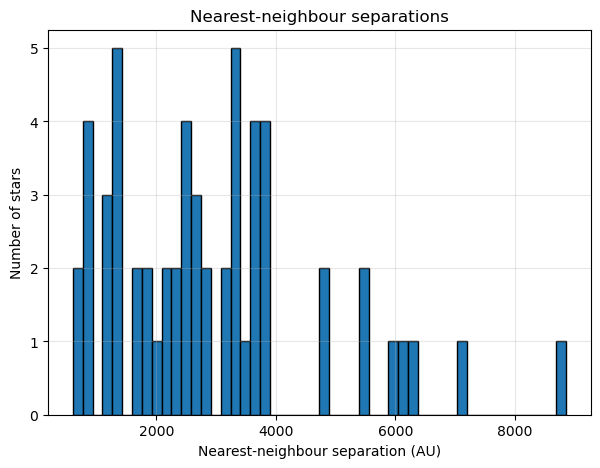

In [34]:
# Use functions on smaller subregion

fake_sub = make_fake_set(onc_sub_2, scale=1)
nn_sub = nearest_neighbours(fake_sub, plot=True, bins=50)

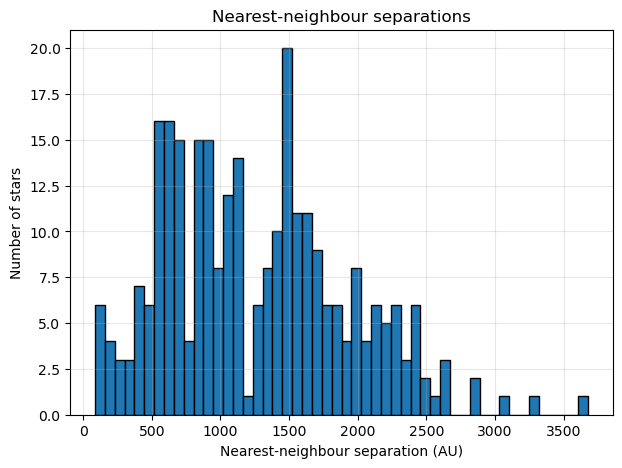

In [35]:
fake_sub_5= make_fake_set(onc_sub_2, scale=5)
nn_sub_5= nearest_neighbours(fake_sub_5, plot=True, bins=50)

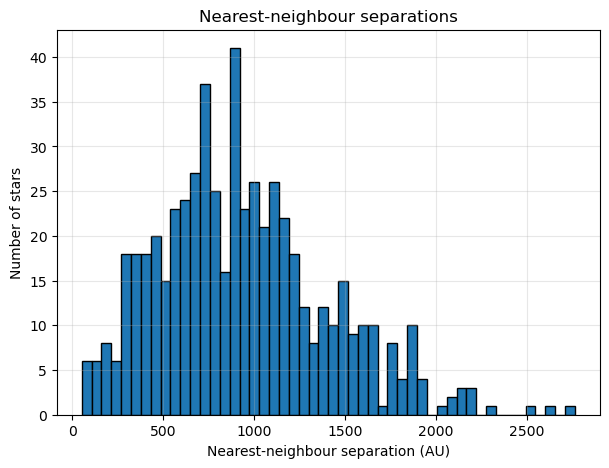

In [36]:
fake_sub_10 = make_fake_set(onc_sub_2, scale=10)
nn_sub_10 = nearest_neighbours(fake_sub_10, plot=True, bins=50)

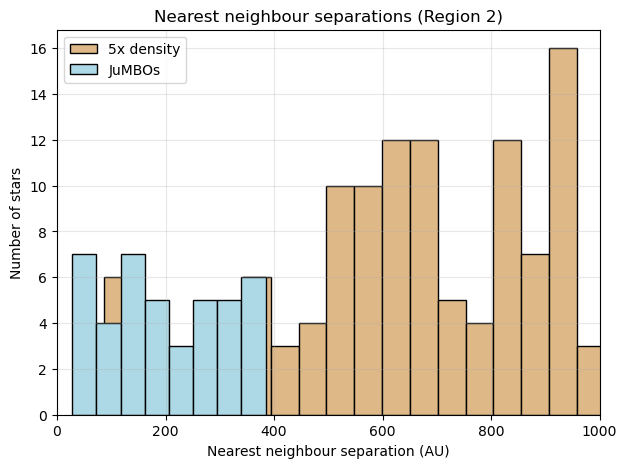

In [37]:
plt.figure(figsize=(7,5))
plt.hist(nn_sub_5["nn_AU"], bins=70, color="burlywood", edgecolor="black", label = '5x density')
plt.hist(jumbos["sep_au"], bins = 8, color='lightblue', edgecolor="black", label = 'JuMBOs')
plt.xlabel("Nearest neighbour separation (AU)")
plt.ylabel("Number of stars")
plt.title("Nearest neighbour separations (Region 2)")
plt.grid(alpha=0.3)
plt.xlim(0, 1000)
plt.legend()
plt.show()

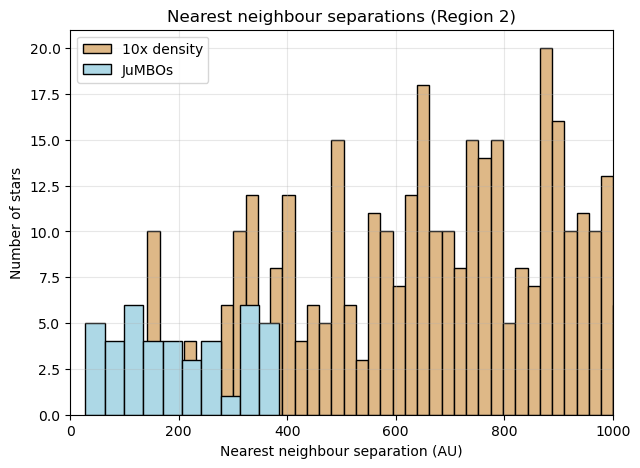

In [38]:
plt.figure(figsize=(7,5))
plt.hist(nn_sub_10["nn_AU"], bins=120, color="burlywood", edgecolor="black", label = '10x density')
plt.hist(jumbos["sep_au"], bins = 10, color='lightblue', edgecolor="black", label = 'JuMBOs')
plt.xlabel("Nearest neighbour separation (AU)")
plt.ylabel("Number of stars")
plt.title("Nearest neighbour separations (Region 2)")
plt.grid(alpha=0.3)
plt.xlim(0, 1000)

plt.legend()
plt.show()

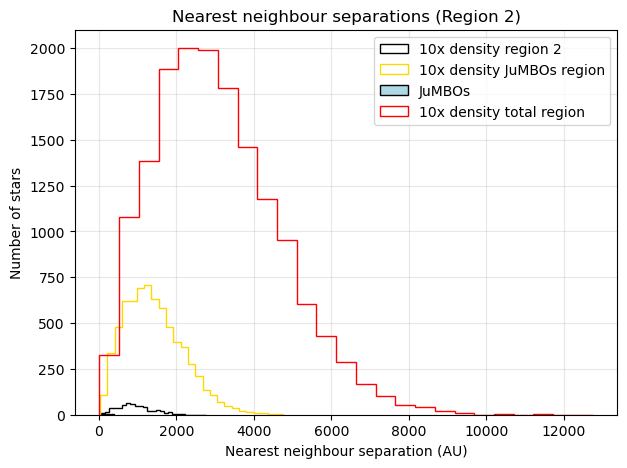

In [39]:
plt.figure(figsize=(7,5))
plt.hist(nn_sub_10["nn_AU"], bins=25, color="burlywood", histtype='step', edgecolor="black", label = '10x density region 2')
plt.hist(nn_sub_10_jumbo["nn_AU"], bins=25, color="burlywood", histtype='step', edgecolor="gold", label = '10x density JuMBOs region')
plt.hist(jumbos["sep_au"], bins = 10, color='lightblue', edgecolor="black", label = 'JuMBOs')
plt.hist(nn_fake10["nn_AU"], bins=25, color="burlywood", histtype='step', edgecolor="red", label = '10x density total region')
plt.xlabel("Nearest neighbour separation (AU)")
plt.ylabel("Number of stars")
plt.title("Nearest neighbour separations (Region 2)")
plt.grid(alpha=0.3)


plt.legend()
plt.show()

In [40]:
#Peaks

def peak_finder(sep, bins=25):
    '''Find peak separation of a histogram
    Inputs:
    sep:  df, contains separations of pairs of stars'''
    
    n, edges = np.histogram(sep, bins=bins)   
    i_peak = int(n.argmax())
    left, right = edges[i_peak], edges[i_peak+1]
    centre = 0.5 * (left + right)
    count = n[i_peak]

    return centre, count

In [41]:
nn_fake10_centre, nn_fake10_count = peak_finder(nn_fake10["nn_AU"])
nn_sub_10_centre, nn_sub_10_count = peak_finder(nn_sub_10["nn_AU"])
nn_sub_10_jumbo_centre, nn_sub_10_jumbo_count = peak_finder(nn_sub_10_jumbo["nn_AU"])

print(f"Peak separation: {nn_fake10_centre:.2f} AU (count = {nn_fake10_count})")
print(f"Peak separation: {nn_sub_10_jumbo_centre:.2f} AU (count = {nn_sub_10_jumbo_count})")
print(f"Peak separation: {nn_sub_10_centre:.2f} AU (count = {nn_sub_10_count})")



Peak separation: 2304.38 AU (count = 2000)
Peak separation: 1256.52 AU (count = 706)
Peak separation: 756.96 AU (count = 62)


In [48]:
df

,ID,RA,Dec,col4,col5,mag,RA_deg,Dec_deg
0,1,5 34 11.42,-5 30 19.44,-1.00,-1.00,17.67,83.547583,-5.505400
1,2,5 34 11.6,-5 33 55.63,0.90,0.42,19.34,83.548333,-5.565453
2,3,5 34 12.81,-5 28 47.81,0.24,0.51,16.80,83.553375,-5.479947
3,4,5 34 12.97,-5 33 48.05,0.49,0.19,18.98,83.554042,-5.563347
4,5,5 34 13.12,-5 33 53.25,-1.00,-1.00,19.00,83.554667,-5.564792
...,...,...,...,...,...,...,...,...
1571,1572,5 36 29.88,-5 31 19.75,-1.00,-1.00,20.01,84.124500,-5.522153
1572,1573,5 36 30.05,-5 20 5.64,-1.00,-1.00,18.70,84.125208,-5.334900
1573,1574,5 36 30.06,-5 26 12.01,0.14,0.39,18.63,84.125250,-5.436669
1574,1575,5 36 30.83,-5 16 27.79,1.67,0.16,19.85,84.128458,-5.274386
